# Exercise Sheet 01

**Introduction to PyTorch and Convolution**  
This notebook contains one code cell per subtask. Complete the `# TODO` sections and keep your outputs visible before exporting the notebook as PDF.

## General Setup

Run the next cell first. It loads the libraries and helper functions that are allowed for the sheet.

Expected file layout: place `Wombat.jpg` in the same directory as this notebook unless a subtask explicitly asks you to load something else yourself.

In [48]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.models as models
from PIL import Image

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['image.cmap'] = 'gray'

IMAGE_PATH = Path('Wombat.jpg')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# You may use this function to normalize arrays for display.
def normalize_for_display(array):
    array = np.asarray(array, dtype=np.float32)
    array_min = array.min()
    array_max = array.max()
    return (array - array_min) / (array_max - array_min + 1e-8)

# You may use this function to display images in the notebook.
def show_image(array, title, cmap=None):
    plt.figure(figsize=(6, 5))
    plt.imshow(array, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()



Using device: cuda


## Task 1: Basic Image Manipulation

### Task 1.1
Load `Wombat.jpg` using a library of your choice and convert it to a NumPy array.

In [49]:
# TODO: Load Wombat.jpg and convert it to a NumPy array called `img`.
img = Image.open('Wombat.jpg')
img = np.array(img)

### Task 1.2
Print the image shape, explain its meaning, and visualize the image with the shape in the title.

(800, 1200, 3)


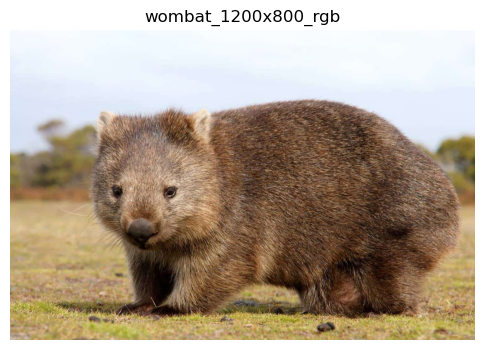

In [50]:
# TODO: Print img.shape, explain the dimensions, and visualize the image.
print(img.shape) # Dimesnions: (image hight, image width, color chanels)

show_image(img, "wombat_1200x800_rgb")

### Task 1.3
Extract a crop of random size centered at the image center and plot it.

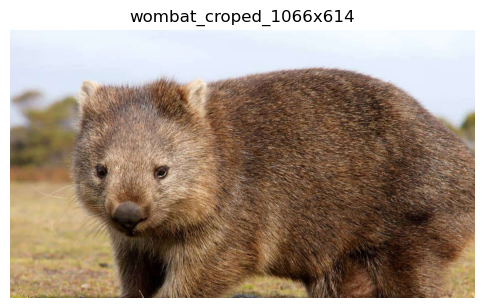

In [51]:
# TODO: Create a random centered crop from `img` and store it in `center_crop`.
h, w, c = img.shape

crop_hight = np.random.randint(1, h)
crop_width = np.random.randint(1, w)

center_x = w//2
center_y = h//2

crop_start_x = center_x - crop_width // 2
crop_end_x = center_x + crop_width // 2
crop_start_y = center_y - crop_hight // 2
crop_end_y = center_y + crop_hight // 2

croped_img = img[crop_start_y:crop_end_y, crop_start_x:crop_end_x]
show_image(croped_img, f"wombat_croped_{crop_width}x{crop_hight}")




### Task 1.4
Randomly permute the RGB color channels of the crop and plot it.

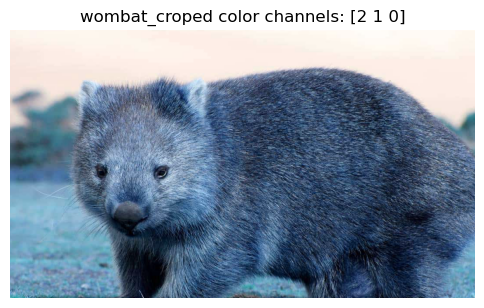

In [52]:
# TODO: Randomly permute the channel order of `center_crop` and store the result in `permuted_crop`.
channels = [0, 1, 2]

channels_perm = np.random.permutation(channels)
img_croped_permuted = croped_img[:,:,channels_perm]

show_image(img_croped_permuted, f"wombat_croped color channels: {channels_perm}")

### Task 1.5
Convert the original image to grayscale and plot it.

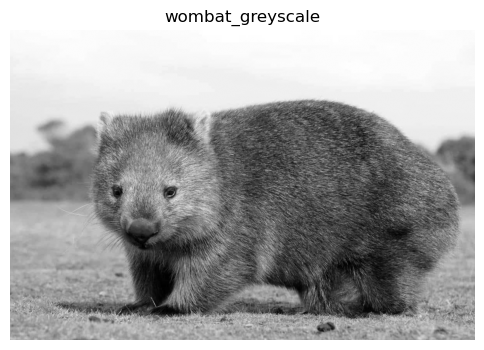

In [53]:
# TODO: Convert `img` to grayscale, store the result in `gray_img`, and visualize it.

grey_values = np.array([0.299, 0.587, 0.114])

img_greyscale = np.dot(img,grey_values)
show_image(img_greyscale, "wombat_greyscale")

### Task 1.6
Insert the color-permuted crop back into the grayscale image and plot the result.

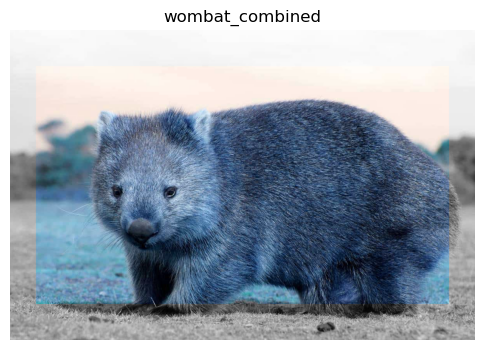

In [54]:
# TODO: Insert `permuted_crop` into the grayscale image and store the result in `gray_with_patch`.
img_combined = np.stack((img_greyscale, img_greyscale, img_greyscale), axis=2) # stack greyscale image three times to simulate the three color channels

img_combined[crop_start_y:crop_end_y, crop_start_x:crop_end_x] = img_croped_permuted
img_combined = img_combined.astype(np.uint8) # convert decimals to integers 

show_image(img_combined, "wombat_combined")


### Task 1.7
Resize the grayscale image with inserted color patch by a factor of 1/4 in width and 1/2 in height.

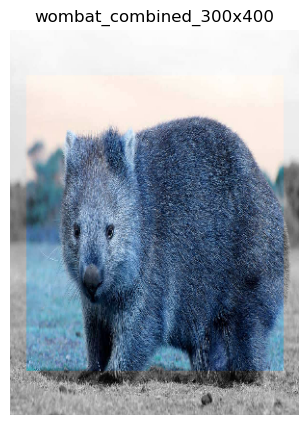

In [55]:
# TODO: Resize `gray_with_patch` to the requested output size and visualize the result.

img_combined_downsampled = img_combined[::2, ::4]
show_image(img_combined_downsampled, f"wombat_combined_{img_combined_downsampled.shape[1]}x{img_combined_downsampled.shape[0]}")


## Task 2: Convolution and Filtering

For this task, implement the required convolutions manually with NumPy. Do not call built-in convolution functions.

### Task 2.1
Implement single-channel convolution for grayscale images.

In [56]:
# TODO: Implement `conv2d_gray`.

def conv2d_gray(image, kernel):
    """Manual 2D convolution / filtering for a single-channel image."""
    h , w = image.shape
    n = kernel.shape[0]
    k = n // 2

    # empty output image
    h_max = h - n + 1
    w_max = w -n +1
    output_img = np.zeros((h_max, w_max))

    for y in range(k, h - k):
        for x in range(k, w  - k):
            patch = image[y-k : y+n-k, x-k : x+n-k]
            pixel_value = np.sum(patch*kernel)

            output_img[y-k, x-k] = pixel_value
    
    return output_img


### Task 2.2
Implement a Gaussian kernel, visualize it, apply it to the grayscale wombat image, and comment on the effect of `n` and `sigma`.

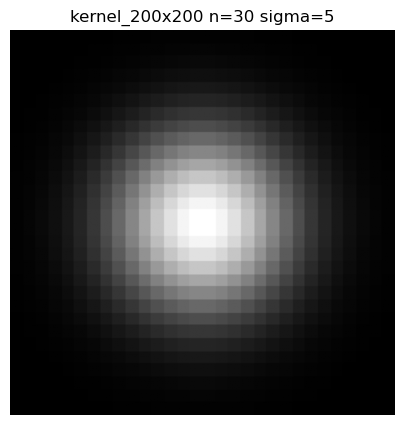

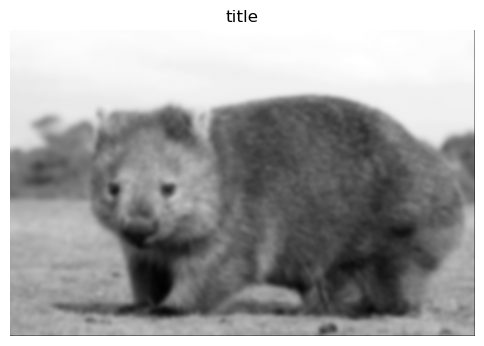

Sigma changes the intensity of the blur, meaning how sharp or soft the image looks. n controlls how many neighbouring pixels are taken into account when calculating the blur. This only becomes visible in the image when n is closer to sigma and the blur gets "cut off"


In [57]:
# TODO: Implement `gaussian_kernel`, apply it, visualize the results, and comment below.

def gaussian_kernel(n, sigma):
    """Return a normalized Gaussian kernel of shape (n, n)."""
    k = n // 2

    # create grid
    grid_line = np.linspace(-k, k, n)
    grid_row, grid_column = np.meshgrid(grid_line, grid_line)
    
    # apply formula
    kernel = np.exp(-(grid_row**2 + grid_column**2) / (2 * sigma**2))
    
    # normalization
    return kernel / np.sum(kernel)

# create kernel and visualize kernel 
n, sigma = 30, 5
kernel = gaussian_kernel(n, sigma)
kernel_display = normalize_for_display(kernel)
kernel_200 = np.array(Image.fromarray(kernel_display, mode='F').resize((200, 200), Image.NEAREST))
show_image(kernel_200, f"kernel_{kernel_200.shape[0]}x{kernel_200.shape[1]} n={n} sigma={sigma}")

# apply kernel
img_greyscale_blured = conv2d_gray(img_greyscale, kernel)
show_image(img_greyscale_blured, "title")


comment_task_2_2 = 'Sigma changes the intensity of the blur, meaning how sharp or soft the image looks. n controlls how many neighbouring pixels are taken into account when calculating the blur. This only becomes visible in the image when n is closer to sigma and the blur gets "cut off"'
print(comment_task_2_2)


### Task 2.3
Extend the convolution implementation to multi-channel inputs.

In [58]:
# TODO: Implement `conv2d_multi`.

def conv2d_multi(image, kernel):
    """Manual convolution for multi-channel input and a single output channel."""
    h, w, c = image.shape
    n = kernel.shape[0]
    k = n // 2

    # empty output image
    h_max = h-n+1
    w_max = w-n+1
    output_img = np.zeros((h_max, w_max))

    for y in range(k, h-k):
        for x in range(k, w-k):
            patch_3d = image[y-k:y+k+1, x-k:x+k+1, :]
            pixel_value = np.sum(patch_3d*kernel)

            output_img[y-k, x-k] = pixel_value

    return output_img



### Task 2.4
Use a 1x1 kernel to convert an RGB image to grayscale, apply it to the original wombat image, and explain the role of the kernel weights.

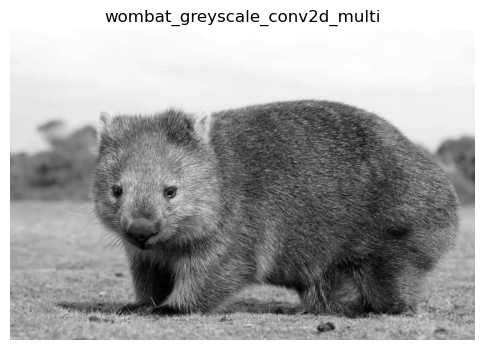

The kernel size is only one pixel so there are no neighbours to take into account. The weights simply specify 
how much each color value (r,g,b) influences the output pixel.


In [59]:
# TODO: Build a 1x1x3 kernel, apply it with `conv2d_multi`, and explain the result below.

kernel_1x1 = np.array([[[0.299, 0.587, 0.114]]])


img_blured = conv2d_multi(img, kernel_1x1)
show_image(img_blured, "wombat_greyscale_conv2d_multi")

answer_task_2_4 = 'The kernel size is only one pixel so there are no neighbours to take into account. The weights simply specify \nhow much each color value (r,g,b) influences the output pixel.'
print(answer_task_2_4)




### Task 2.5
Discuss limitations of manually designed filters and advantages of learning filters from data.

In [60]:
# TODO: Replace the text below with your discussion.

discussion_task_2_5 = """
Even though manual filters are more predictable, they can be very hard to design when their purpose becomes more complex.
They also require manual work of humans for the design process.

Learning filters from data on the other hand can lead to the discovery of complex patterns which a human might have overseen.
This also allowes the development of complex filters in the background without permanent supervision of a human.
"""
print(discussion_task_2_5)



Even though manual filters are more predictable, they can be very hard to design when their purpose becomes more complex.
They also require manual work of humans for the design process.

Learning filters from data on the other hand can lead to the discovery of complex patterns which a human might have overseen.
This also allowes the development of complex filters in the background without permanent supervision of a human.



## Task 3: Network Visualization and Interpretation

### Task 3.1
Load pretrained AlexNet, print its architecture, identify the first convolutional layer, and explain its weight tensor shape.

In [61]:
# TODO: Load pretrained AlexNet, inspect the first convolutional layer, and explain it below.

shape_explanation_task_3_1 = 'TODO: Explain the meaning of the first-layer weight tensor dimensions.'
print(shape_explanation_task_3_1)

raise NotImplementedError('Task 3.1: load AlexNet and inspect the first convolutional layer.')


TODO: Explain the meaning of the first-layer weight tensor dimensions.


NotImplementedError: Task 3.1: load AlexNet and inspect the first convolutional layer.

### Task 3.2
Visualize all learned filters of the first convolutional layer.

In [ ]:
# TODO: Extract and visualize the filters of the first convolutional layer.

raise NotImplementedError('Task 3.2: visualize the first-layer filters.')


### Task 3.3
Discuss what you observe in the first-layer filters.

In [ ]:
# TODO: Replace the text below with your discussion.

discussion_task_3_3 = """
TODO: Comment on patterns such as:
- color contrasts
- oriented edges
- intensity transitions
- why these are useful early visual features
"""
print(discussion_task_3_3)


### Task 3.4-3.7
Compute a saliency map for the predicted class of `Wombat.jpg`.

Work through the following subtasks:
1. Determine the predicted class of the image.
2. Compute the gradient of the predicted class score with respect to the input image.
3. Construct and visualize the saliency map.
4. Briefly explain what high saliency values mean in this context.

In [ ]:
# TODO 3.4: Load `Wombat.jpg`, preprocess it with the pretrained AlexNet transforms,
# and determine the predicted class.

predicted_class_idx = None
predicted_class_label = 'TODO'

print(f'Predicted class index: {predicted_class_idx}')
print(f'Predicted class label: {predicted_class_label}')

# TODO 3.5: Compute the gradient of the predicted class score with respect to the input image.
# Hint: enable gradients for the input, reset gradients with `model.zero_grad()`,
# and call `score.backward()`.

gradient_wrt_input = None

# TODO 3.6: Construct the saliency map by taking the absolute gradient and collapsing
# the color channels into one 2D map (for example via a maximum over channels).
# Visualize the input image and the saliency map side by side.

saliency_map = None

# TODO 3.7: Replace the text below with your discussion.

answer_task_3_7 = 'TODO: Explain what high saliency values mean in this context and what the map reveals about the network decision.'
print(answer_task_3_7)

raise NotImplementedError('Task 3.4-3.7: complete all four saliency subtasks.')


## Submission Reminder

Before submission, make sure that:
- all `# TODO` sections are completed,
- all requested plots are visible in the notebook output,
- the notebook is exported as PDF,
- the `.ipynb` and PDF are included in the ZIP file following the naming convention from the sheet.